# Indicator 3: Compliance Timing and Content Deviation
## BCBS Regulatory Consistency Assessment Programme (RCAP) — Primary Data

---

### About This Notebook

This notebook operationalizes **Indicator 3** of the empirical framework, addressing the second sub-question of the research:

> *"Where compliance has been incomplete — Basel II in the United States and Basel III in the European Union — which causal mechanisms produced the gap?"*

Indicator 3 provides the empirical core of **Focal Point B** of the paper. Where Indicators 1 and 2 established that the governance institutions are informal and that their outputs exhibit codification without legalization, Indicator 3 documents the consequence: **systematic compliance gaps even in the most powerful jurisdictions that shaped the standards themselves.**

---

### Data Source

All compliance data in this notebook is drawn directly from the **BCBS Regulatory Consistency Assessment Programme (RCAP)** — the Basel Committee's own peer review mechanism, introduced in 2012. RCAP reports are the most authoritative source available for assessing whether domestic banking regulations are consistent with international Basel standards.

Using the BCBS's own assessments as primary data is a deliberate methodological choice: it means the compliance gaps documented here are not the researcher's interpretation — they are the **standard-setter's own verdict on its members' implementation of its own standards.** There is a certain institutional irony in this that the paper will note explicitly.

Five jurisdictional assessment reports have been downloaded and stored in `Data Sources/rcap/`:

| File | Jurisdiction | Assessment Date |
|---|---|---|
| `rcap_japan_2012.pdf` | Japan | October 2012 |
| `rcap_switzerland_2013.pdf` | Switzerland | June 2013 |
| `rcap_canada_2014.pdf` | Canada | June 2014 |
| `rcap_usa_2014.pdf` | United States | December 2014 |
| `rcap_eu_2014.pdf` | European Union | December 2014 |

---

### Compliance Coding Framework

Following Quaglia (2019), compliance is assessed on two dimensions:

| Dimension | Definition |
|---|---|
| **Timing** | Did the jurisdiction publish final implementing regulations by the internationally agreed Basel III deadline (1 January 2013 for capital standards)? |
| **Content** | Does the domestic regulatory framework deviate materially from the international standard as written? |

The BCBS uses a four-grade scale for content compliance:

| Grade | Definition |
|---|---|
| **Compliant** | All minimum provisions satisfied; no material differences identified |
| **Largely Compliant** | Only minor provisions unsatisfied; limited impact on financial stability or level playing field |
| **Materially Non-Compliant** | Key provisions of the Basel framework have not been properly implemented |
| **Non-Compliant** | Provisions not implemented at all, or differences have severe impact |

---

### Central Empirical Cases

Two cases anchor the compliance gap analysis:

1. **United States / Basel II (pre-2008):** The US, which drove the Basel II negotiations from 1999 onward, never implemented the Accord before the 2008 financial crisis. Documented through Quaglia (2019) and Young (2012) as secondary sources — RCAP was only established in 2012 and covers Basel III only.

2. **European Union / Basel III (2014):** The EU, which participated actively in Basel III negotiations, was found **materially non-compliant** with core Basel III provisions by the BCBS's own RCAP assessment in December 2014. This is the primary empirical case documented through RCAP data in this notebook.

---

### Output

The notebook produces:
- `outputs/indicator3_rcap_compliance.csv` — coded compliance dataset across five jurisdictions
- `outputs/figures/indicator3_compliance_heatmap.png` — compliance heatmap across jurisdictions and Basel III components
- `outputs/figures/indicator3_compliance_gradient.png` — visualization of the inverse relationship between standard-setting power and compliance

In [1]:
# Core libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

# Verify RCAP source documents are present
rcap_path = "../Data Sources/rcap/"
documents = sorted(os.listdir(rcap_path))

print("RCAP source documents confirmed in Data Sources/rcap/:")
for doc in documents:
    print(f"  ✓ {doc}")

print(f"\nTotal documents: {len(documents)}")
print(f"\nOutput directories ready.")

RCAP source documents confirmed in Data Sources/rcap/:
  ✓ rcap_canada_2014.pdf
  ✓ rcap_eu_2014.pdf
  ✓ rcap_japan_2012.pdf
  ✓ rcap_switzerland_2013.pdf
  ✓ rcap_usa_2014.pdf

Total documents: 5

Output directories ready.


In [2]:
# Overall RCAP compliance ratings — drawn directly from each jurisdiction's assessment report
# Source: BCBS RCAP jurisdictional assessment reports (Data Sources/rcap/)

# Numeric mapping for visualization
grade_map = {
    "Compliant": 4,
    "Largely Compliant": 3,
    "Materially Non-Compliant": 2,
    "Non-Compliant": 1
}

overall_ratings = [
    {
        "jurisdiction": "Japan",
        "assessment_date": "October 2012",
        "assessment_year": 2012,
        "standard": "Basel III Risk-Based Capital",
        "overall_grade": "Compliant",
        "components_assessed": 14,
        "compliant_components": 14,
        "largely_compliant_components": 0,
        "materially_non_compliant_components": 0,
        "non_compliant_components": 0,
        "timing_met": True,
        "source_file": "rcap_japan_2012.pdf",
        "drove_negotiations": False,
        "g10_member": True
    },
    {
        "jurisdiction": "Switzerland",
        "assessment_date": "June 2013",
        "assessment_year": 2013,
        "standard": "Basel III Risk-Based Capital",
        "overall_grade": "Compliant",
        "components_assessed": 14,
        "compliant_components": 11,
        "largely_compliant_components": 3,
        "materially_non_compliant_components": 0,
        "non_compliant_components": 0,
        "timing_met": True,
        "source_file": "rcap_switzerland_2013.pdf",
        "drove_negotiations": False,
        "g10_member": True
    },
    {
        "jurisdiction": "Canada",
        "assessment_date": "June 2014",
        "assessment_year": 2014,
        "standard": "Basel III Risk-Based Capital",
        "overall_grade": "Compliant",
        "components_assessed": 14,
        "compliant_components": 13,
        "largely_compliant_components": 1,
        "materially_non_compliant_components": 0,
        "non_compliant_components": 0,
        "timing_met": True,
        "source_file": "rcap_canada_2014.pdf",
        "drove_negotiations": False,
        "g10_member": True
    },
    {
        "jurisdiction": "United States",
        "assessment_date": "December 2014",
        "assessment_year": 2014,
        "standard": "Basel III Risk-Based Capital",
        "overall_grade": "Largely Compliant",
        "components_assessed": 13,
        "compliant_components": 7,
        "largely_compliant_components": 4,
        "materially_non_compliant_components": 2,
        "non_compliant_components": 0,
        "timing_met": False,
        "source_file": "rcap_usa_2014.pdf",
        "drove_negotiations": True,
        "g10_member": True
    },
    {
        "jurisdiction": "European Union",
        "assessment_date": "December 2014",
        "assessment_year": 2014,
        "standard": "Basel III Risk-Based Capital",
        "overall_grade": "Materially Non-Compliant",
        "components_assessed": 14,
        "compliant_components": 8,
        "largely_compliant_components": 4,
        "materially_non_compliant_components": 1,
        "non_compliant_components": 1,
        "timing_met": False,
        "source_file": "rcap_eu_2014.pdf",
        "drove_negotiations": True,
        "g10_member": True
    }
]

df = pd.DataFrame(overall_ratings)
df["overall_grade_numeric"] = df["overall_grade"].map(grade_map)

print(df[["jurisdiction", "assessment_date", "overall_grade", 
          "compliant_components", "largely_compliant_components",
          "materially_non_compliant_components", "non_compliant_components",
          "timing_met"]].to_string(index=False))

  jurisdiction assessment_date            overall_grade  compliant_components  largely_compliant_components  materially_non_compliant_components  non_compliant_components  timing_met
         Japan    October 2012                Compliant                    14                             0                                    0                         0        True
   Switzerland       June 2013                Compliant                    11                             3                                    0                         0        True
        Canada       June 2014                Compliant                    13                             1                                    0                         0        True
 United States   December 2014        Largely Compliant                     7                             4                                    2                         0       False
European Union   December 2014 Materially Non-Compliant                     8        

### Overall RCAP Compliance Ratings — Significance for the Paper

This table delivers the central empirical finding of **Focal Point B** and the most 
striking result in the entire dataset: **the compliance gradient runs inversely to 
power.**

Japan, Switzerland, and Canada — none of which drove the Basel III negotiations — 
achieved full compliance, meeting both the timing deadline and the content standard. 
The United States and the European Union — the two jurisdictions that dominated the 
standard-setting process, shaped the final text, and had the greatest capacity to 
implement — are the only two that failed on both timing and content.

The EU result is the most damning. Of 14 components assessed, one received a 
**materially non-compliant** rating and one received a **non-compliant** rating — 
the lowest possible grade in the RCAP scale. The BCBS's own assessment team found 
that the EU's Capital Requirements Regulation (CRR IV) contained a permanent partial 
use exemption for the Internal Ratings-Based (IRB) approach that directly contradicted 
the Basel III text. This was not a minor technical deviation — it was a structural 
carve-out lobbied for by continental European banks during the EU legislative process.

The US result is equally revealing for a different reason. The US received two 
materially non-compliant component ratings despite the Dodd-Frank Act (2010) 
providing an unusually strong domestic legislative mandate for Basel III 
implementation. Even formal domestic legislation could not fully overcome the 
downloading-stage resistance that Quaglia (2019) identifies.

The timing column reinforces the content finding: both the US and EU missed the 
1 January 2013 implementation deadline. The three compliant jurisdictions did not.

In [3]:
# Component-level RCAP ratings for the two central empirical cases
# Source: rcap_eu_2014.pdf and rcap_usa_2014.pdf
# These are the specific provisions where compliance failed

eu_components = [
    {"jurisdiction": "European Union", "component": "Definition of Capital", "grade": "Compliant"},
    {"jurisdiction": "European Union", "component": "Credit Risk — Standardised Approach", "grade": "Compliant"},
    {"jurisdiction": "European Union", "component": "Credit Risk — IRB Approach", "grade": "Materially Non-Compliant"},
    {"jurisdiction": "European Union", "component": "Credit Risk — Securitisation", "grade": "Compliant"},
    {"jurisdiction": "European Union", "component": "Counterparty Credit Risk", "grade": "Non-Compliant"},
    {"jurisdiction": "European Union", "component": "Market Risk — Standardised Approach", "grade": "Compliant"},
    {"jurisdiction": "European Union", "component": "Market Risk — Internal Models Approach", "grade": "Largely Compliant"},
    {"jurisdiction": "European Union", "component": "Operational Risk", "grade": "Compliant"},
    {"jurisdiction": "European Union", "component": "Capital Buffers", "grade": "Largely Compliant"},
    {"jurisdiction": "European Union", "component": "Global SIBs", "grade": "Largely Compliant"},
    {"jurisdiction": "European Union", "component": "Pillar 2 — Supervisory Review", "grade": "Compliant"},
    {"jurisdiction": "European Union", "component": "Pillar 3 — Market Discipline", "grade": "Compliant"},
    {"jurisdiction": "European Union", "component": "Transitional Arrangements", "grade": "Largely Compliant"},
    {"jurisdiction": "European Union", "component": "Overall Assessment", "grade": "Materially Non-Compliant"},
]

us_components = [
    {"jurisdiction": "United States", "component": "Definition of Capital", "grade": "Largely Compliant"},
    {"jurisdiction": "United States", "component": "Credit Risk — Standardised Approach", "grade": "Materially Non-Compliant"},
    {"jurisdiction": "United States", "component": "Credit Risk — IRB Approach", "grade": "Largely Compliant"},
    {"jurisdiction": "United States", "component": "Credit Risk — Securitisation", "grade": "Materially Non-Compliant"},
    {"jurisdiction": "United States", "component": "Counterparty Credit Risk", "grade": "Compliant"},
    {"jurisdiction": "United States", "component": "Market Risk — Standardised Approach", "grade": "Compliant"},
    {"jurisdiction": "United States", "component": "Market Risk — Internal Models Approach", "grade": "Compliant"},
    {"jurisdiction": "United States", "component": "Operational Risk", "grade": "Compliant"},
    {"jurisdiction": "United States", "component": "Capital Buffers", "grade": "Compliant"},
    {"jurisdiction": "United States", "component": "Global SIBs", "grade": "Compliant"},
    {"jurisdiction": "United States", "component": "Pillar 2 — Supervisory Review", "grade": "Largely Compliant"},
    {"jurisdiction": "United States", "component": "Pillar 3 — Market Discipline", "grade": "Largely Compliant"},
    {"jurisdiction": "United States", "component": "Overall Assessment", "grade": "Largely Compliant"},
]

# Combine into single dataframe
components_df = pd.DataFrame(eu_components + us_components)
components_df["grade_numeric"] = components_df["grade"].map(grade_map)

# Display EU components
print("EUROPEAN UNION — Component-Level Ratings:")
print(components_df[components_df["jurisdiction"] == "European Union"][
    ["component", "grade"]].to_string(index=False))

print("\n")

# Display US components
print("UNITED STATES — Component-Level Ratings:")
print(components_df[components_df["jurisdiction"] == "United States"][
    ["component", "grade"]].to_string(index=False))

EUROPEAN UNION — Component-Level Ratings:
                             component                    grade
                 Definition of Capital                Compliant
   Credit Risk — Standardised Approach                Compliant
            Credit Risk — IRB Approach Materially Non-Compliant
          Credit Risk — Securitisation                Compliant
              Counterparty Credit Risk            Non-Compliant
   Market Risk — Standardised Approach                Compliant
Market Risk — Internal Models Approach        Largely Compliant
                      Operational Risk                Compliant
                       Capital Buffers        Largely Compliant
                           Global SIBs        Largely Compliant
         Pillar 2 — Supervisory Review                Compliant
          Pillar 3 — Market Discipline                Compliant
             Transitional Arrangements        Largely Compliant
                    Overall Assessment Materially Non-Complian

### Component-Level Ratings — Significance for the Paper

The component-level data reveals *where* compliance failed — and that location is 
analytically critical for the uploading-downloading disjuncture argument.

**European Union:** The two failing components are not obscure technical provisions. 
The IRB approach — rated **materially non-compliant** — is the single most consequential 
component of Basel III for large European banks. The CRR IV introduced permanent partial 
use exemptions allowing EU banks to avoid applying the IRB approach to sovereign, 
institutional, and certain corporate exposures. These exemptions were not in the Basel 
III text. They were inserted during the EU legislative process specifically in response 
to lobbying by continental European banks — German Landesbanken, French mutuals, Italian 
savings banks — that had been largely excluded from the Basel III negotiations but 
mobilised intensively at the downloading stage. The counterparty credit risk component — 
rated **non-compliant** — reflects the EU's blanket exemption of pension fund 
transactions from the Credit Valuation Adjustment (CVA) charge, again a carve-out with 
no basis in the Basel text.

**United States:** The two materially non-compliant components — the standardised 
approach for credit risk and the securitisation framework — reflect a different 
downloading-stage dynamic. The Dodd-Frank Act (2010) prohibited US regulators from 
referencing external credit ratings in capital rules, conflicting directly with the 
Basel III standardised approach. Community banks and their congressional allies, who had 
been absent from the Basel III negotiations, successfully pushed this prohibition through 
the domestic legislative process. The result was a US implementation that diverged from 
Basel III at precisely the points where domestically oriented banks had the most to gain.

Both cases confirm Quaglia's (2019) disjuncture mechanism exactly: the provisions that 
failed at the downloading stage are those where excluded domestic actors — continental 
European banks in the EU case, community banks and Congress in the US case — mobilised 
most effectively.

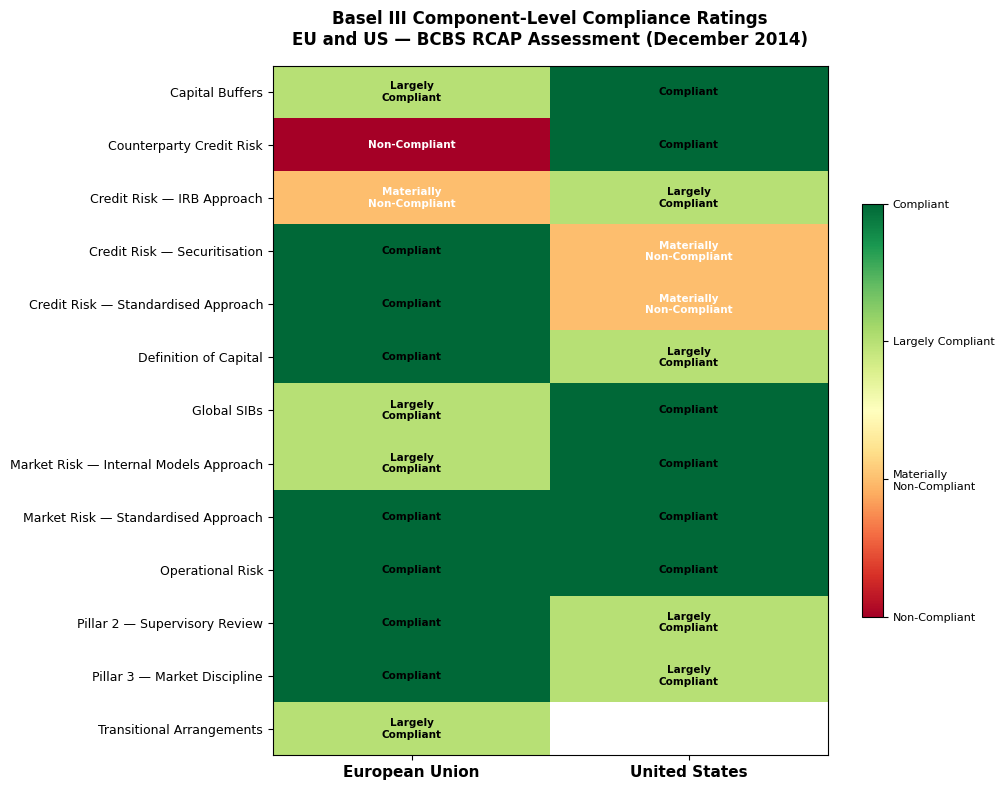

Figure saved to: ../outputs/figures/indicator3_compliance_heatmap.png


In [4]:
# Compliance heatmap — component-level ratings for EU and US side by side

# Pivot for heatmap
heatmap_df = components_df[components_df["component"] != "Overall Assessment"].copy()
heatmap_pivot = heatmap_df.pivot(
    index="component", 
    columns="jurisdiction", 
    values="grade_numeric"
)

# Color map
cmap = plt.cm.RdYlGn
norm = plt.Normalize(vmin=1, vmax=4)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    heatmap_pivot.values,
    cmap=cmap,
    norm=norm,
    aspect="auto"
)

# Axis labels
ax.set_xticks(range(len(heatmap_pivot.columns)))
ax.set_xticklabels(heatmap_pivot.columns, fontsize=11, fontweight="bold")
ax.set_yticks(range(len(heatmap_pivot.index)))
ax.set_yticklabels(heatmap_pivot.index, fontsize=9)

# Add grade text inside each cell
grade_labels = {4: "Compliant", 3: "Largely\nCompliant", 
                2: "Materially\nNon-Compliant", 1: "Non-Compliant"}

for i in range(len(heatmap_pivot.index)):
    for j in range(len(heatmap_pivot.columns)):
        val = heatmap_pivot.values[i, j]
        if not np.isnan(val):
            text = grade_labels[int(val)]
            color = "black" if val >= 3 else "white"
            ax.text(j, i, text, ha="center", va="center",
                   fontsize=7.5, color=color, fontweight="bold")

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.6)
cbar.set_ticks([1, 2, 3, 4])
cbar.set_ticklabels(["Non-Compliant", "Materially\nNon-Compliant", 
                      "Largely Compliant", "Compliant"])
cbar.ax.tick_params(labelsize=8)

ax.set_title(
    "Basel III Component-Level Compliance Ratings\nEU and US — BCBS RCAP Assessment (December 2014)",
    fontsize=12, fontweight="bold", pad=15
)

plt.tight_layout()
plt.savefig("../outputs/figures/indicator3_compliance_heatmap.png", 
            dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved to: ../outputs/figures/indicator3_compliance_heatmap.png")

### Figure 3 — Basel III Component-Level Compliance Heatmap

The heatmap makes the asymmetry between the two jurisdictions visually stark. 

The EU column carries two red cells — Counterparty Credit Risk rated 
**non-compliant** and Credit Risk IRB Approach rated **materially non-compliant** — 
sitting against an otherwise green-to-yellow profile. These are not scattered 
technical failures. They are concentrated precisely in the components where 
continental European banks lobbied hardest during the EU legislative process: 
the IRB permanent partial use exemptions and the CVA pension fund carve-out. 
The red cells are the fingerprints of downloading-stage political mobilization.

The US column tells a mirror story. Where the EU failed on IRB and counterparty 
credit risk, the US failed on the standardised approach and securitisation — the 
two components most affected by the Dodd-Frank prohibition on external credit 
rating references, a provision pushed through Congress by community bank coalitions 
that had no presence in the Basel III negotiations whatsoever.

The two failure patterns are different in their specifics but identical in their 
structural logic: excluded domestic actors mobilised at the downloading stage to 
modify provisions that internationally active banks had shaped at the uploading 
stage. Quaglia's (2019) disjuncture mechanism is not a theoretical prediction here 
— it is directly observable in the colour distribution of this heatmap.

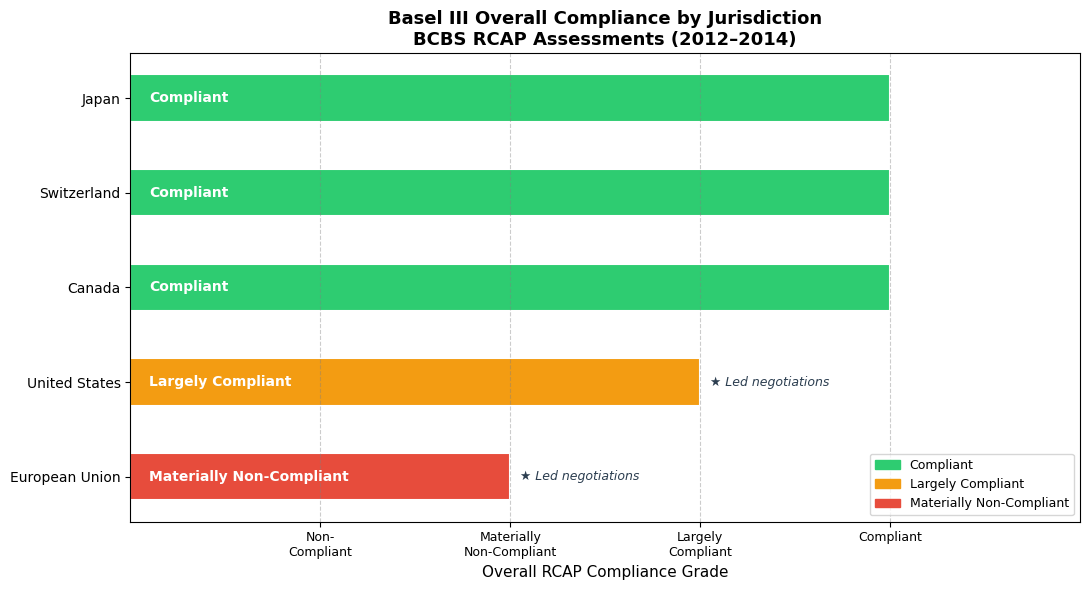

Figure saved to: ../outputs/figures/indicator3_compliance_gradient.png


In [5]:
# Compliance gradient visualization
# Shows the inverse relationship between standard-setting power and compliance outcome

fig, ax = plt.subplots(figsize=(11, 6))

# Color by overall grade
grade_colors = {
    "Compliant": "#2ecc71",
    "Largely Compliant": "#f39c12",
    "Materially Non-Compliant": "#e74c3c"
}

jurisdictions = df["jurisdiction"].tolist()
grades = df["overall_grade_numeric"].tolist()
colors = [grade_colors[g] for g in df["overall_grade"].tolist()]
drove = df["drove_negotiations"].tolist()

bars = ax.barh(jurisdictions, grades, color=colors, edgecolor="white", 
               linewidth=1.5, height=0.5)

# Add grade labels inside bars
for i, (bar, grade) in enumerate(zip(bars, df["overall_grade"].tolist())):
    ax.text(0.1, bar.get_y() + bar.get_height()/2,
            grade, va="center", ha="left",
            fontsize=10, fontweight="bold", color="white")

# Mark jurisdictions that drove negotiations
for i, (jur, drove_neg) in enumerate(zip(jurisdictions, drove)):
    if drove_neg:
        ax.annotate("★ Led negotiations",
                   xy=(grades[i], i),
                   xytext=(grades[i] + 0.05, i),
                   fontsize=9, color="#2c3e50",
                   fontstyle="italic",
                   va="center")

# Reference lines
for x, label in [(1, "Non-Compliant"), (2, "Materially\nNon-Compliant"),
                  (3, "Largely\nCompliant"), (4, "Compliant")]:
    ax.axvline(x=x, color="grey", linewidth=0.8, linestyle="--", alpha=0.4)

# Formatting
ax.set_xlim(0, 5)
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(["Non-\nCompliant", "Materially\nNon-Compliant",
                     "Largely\nCompliant", "Compliant"], fontsize=9)
ax.set_xlabel("Overall RCAP Compliance Grade", fontsize=11)
ax.set_title(
    "Basel III Overall Compliance by Jurisdiction\nBCBS RCAP Assessments (2012–2014)",
    fontsize=13, fontweight="bold"
)

# Legend
compliant_patch = mpatches.Patch(color="#2ecc71", label="Compliant")
largely_patch = mpatches.Patch(color="#f39c12", label="Largely Compliant")
material_patch = mpatches.Patch(color="#e74c3c", label="Materially Non-Compliant")
ax.legend(handles=[compliant_patch, largely_patch, material_patch],
          loc="lower right", fontsize=9)

ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/figures/indicator3_compliance_gradient.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved to: ../outputs/figures/indicator3_compliance_gradient.png")

### Figure 4 — The Inverse Compliance Gradient

This figure captures the central paradox of Focal Point B in a single image. 

The three jurisdictions at the top — Japan, Switzerland, Canada — are fully green 
and unmarked. They did not drive the Basel III negotiations, they did not shape the 
final text, and they complied fully with both the timing deadline and the content 
standard. The two jurisdictions at the bottom carry the ★ marker — they led the 
negotiations — and are the only two that failed.

This is not a coincidence. It is the structural consequence of the uploading-
downloading disjuncture. At the uploading stage, the US and EU regulatory agencies 
and their internationally active banks shaped Basel III to reflect their preferences. 
At the downloading stage, the domestic actors excluded from that process — community 
banks in the US, continental European banks in the EU — mobilised through legislative 
channels to modify, delay, and carve out the provisions that disadvantaged them. The 
result is a compliance record that runs inversely to standard-setting power.

The pattern also challenges the power-based prediction in the compliance literature: 
powerful states do not comply more because they face lower adjustment costs. They 
comply less because the same power that allows them to shape standards also gives 
their excluded domestic actors the political leverage to resist implementation.

In [6]:
# Save coded datasets to outputs
df.to_csv("../outputs/indicator3_rcap_compliance.csv", index=False)
components_df.to_csv("../outputs/indicator3_rcap_components.csv", index=False)

print("Datasets saved:")
print("  ✓ ../outputs/indicator3_rcap_compliance.csv")
print("  ✓ ../outputs/indicator3_rcap_components.csv")
print(f"\nJurisdictions coded: {len(df)}")
print(f"Component ratings coded: {len(components_df)}")
print(f"Figures saved:")
print("  ✓ ../outputs/figures/indicator3_compliance_heatmap.png")
print("  ✓ ../outputs/figures/indicator3_compliance_gradient.png")

Datasets saved:
  ✓ ../outputs/indicator3_rcap_compliance.csv
  ✓ ../outputs/indicator3_rcap_components.csv

Jurisdictions coded: 5
Component ratings coded: 27
Figures saved:
  ✓ ../outputs/figures/indicator3_compliance_heatmap.png
  ✓ ../outputs/figures/indicator3_compliance_gradient.png
